<a href="https://colab.research.google.com/github/chiragpatel11226/machinelearningjournetpart1/blob/main/LoadDemand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import  warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [28]:
df = pd.read_csv("load_forecasting_dataset_corrected.csv", on_bad_lines='skip')

In [29]:
df.shape


(189888, 15)

In [30]:
df.isnull().sum()

,0
Timestamp,0
Temperature (°C),0
Humidity (%),0
Wind Speed (m/s),0
Rainfall (mm),0
Solar Irradiance (W/m²),0
GDP (LKR),0
Per Capita Energy Use (kWh),0
Electricity Price (LKR/kWh),0
Day of Week,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189888 entries, 0 to 189887
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Timestamp                    189888 non-null  object 
 1   Temperature (°C)             189888 non-null  float64
 2   Humidity (%)                 189888 non-null  float64
 3   Wind Speed (m/s)             189888 non-null  float64
 4   Rainfall (mm)                189888 non-null  float64
 5   Solar Irradiance (W/m²)      189888 non-null  float64
 6   GDP (LKR)                    189888 non-null  float64
 7   Per Capita Energy Use (kWh)  189888 non-null  float64
 8   Electricity Price (LKR/kWh)  189888 non-null  float64
 9   Day of Week                  189888 non-null  int64  
 10  Hour of Day                  189888 non-null  int64  
 11  Month                        189888 non-null  int64  
 12  Season                       189888 non-null  object 
 13 

In [32]:
df.describe()

,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Public Event,Load Demand (kW)
count,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000,189888.000000
mean,28.001544,79.998447,1.996106,5.014217,249.938317,1000.083804,499.909985,24.998521,3.001011,11.500000,6.253286,0.049650,1500.154422
std,1.999267,5.002994,1.002337,5.016601,50.008961,50.015166,20.040060,4.998985,1.998741,6.922205,3.465723,0.217222,199.926679
min,19.068792,57.930570,-2.829436,0.000004,53.558277,779.558268,407.111625,3.268386,0.000000,0.000000,1.000000,0.000000,606.879227
25%,26.652234,76.621433,1.317979,1.435887,216.176066,966.274369,486.400599,21.623224,1.000000,5.750000,3.000000,0.000000,1365.223394
50%,28.002750,80.003040,1.995783,3.480060,249.871247,1000.001997,499.947457,25.010508,3.000000,11.500000,6.000000,0.000000,1500.274982
75%,29.350713,83.368748,2.673888,6.954906,283.683824,1033.802397,513.405061,28.376540,5.000000,17.250000,9.000000,0.000000,1635.071296
max,37.124229,101.096832,6.301848,59.219061,449.497275,1251.690264,592.327679,47.420391,6.000000,23.000000,12.000000,1.000000,2412.422945


<Axes: xlabel='Electricity Price (LKR/kWh)', ylabel='Count'>

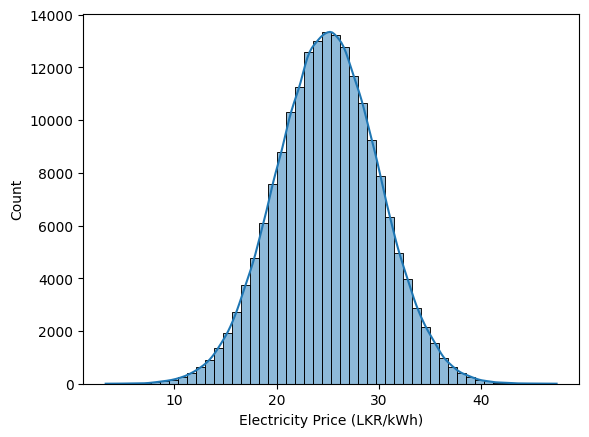

In [33]:
sns.histplot(df['Electricity Price (LKR/kWh)'],bins=50,kde=True)

In [34]:
df.columns

Index(['Timestamp', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)',
       'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'GDP (LKR)',
       'Per Capita Energy Use (kWh)', 'Electricity Price (LKR/kWh)',
       'Day of Week', 'Hour of Day', 'Month', 'Season', 'Public Event',
       'Load Demand (kW)'],
      dtype='object')

In [35]:
df.corr(numeric_only=True)

,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Public Event,Load Demand (kW)
Temperature (°C),1.000000,-0.001357,-0.001318,-0.004504,0.001682,0.001159,0.001494,0.002754,-4.717902e-04,-2.629245e-03,-1.374656e-03,-0.005031,1.000000
Humidity (%),-0.001357,1.000000,0.000287,0.000366,-0.001544,0.001753,0.001530,0.000213,3.362034e-04,1.154186e-03,1.763152e-03,-0.001304,-0.001357
Wind Speed (m/s),-0.001318,0.000287,1.000000,-0.002618,0.001347,0.001046,0.000508,-0.000268,1.554139e-03,-7.344214e-04,-6.396083e-04,0.001705,-0.001318
Rainfall (mm),-0.004504,0.000366,-0.002618,1.000000,-0.002379,0.000204,-0.003120,0.001381,-1.763239e-03,3.866523e-03,2.225346e-03,0.000342,-0.004504
Solar Irradiance (W/m²),0.001682,-0.001544,0.001347,-0.002379,1.000000,-0.000371,0.001443,-0.002925,1.191996e-03,-6.374529e-04,9.260255e-04,-0.001039,0.001682
GDP (LKR),0.001159,0.001753,0.001046,0.000204,-0.000371,1.000000,0.001858,0.000476,4.567340e-04,3.706945e-03,2.554727e-03,0.000008,0.001159
Per Capita Energy Use (kWh),0.001494,0.001530,0.000508,-0.003120,0.001443,0.001858,1.000000,0.001305,-1.386017e-03,2.324787e-03,1.833130e-03,0.000750,0.001494
Electricity Price (LKR/kWh),0.002754,0.000213,-0.000268,0.001381,-0.002925,0.000476,0.001305,1.000000,2.956092e-03,1.500440e-03,-8.953000e-04,-0.000442,0.002754
Day of Week,-0.000472,0.000336,0.001554,-0.001763,0.001192,0.000457,-0.001386,0.002956,1.000000e+00,1.764715e-18,6.198815e-04,-0.000164,-0.000472
Hour of Day,-0.002629,0.001154,-0.000734,0.003867,-0.000637,0.003707,0.002325,0.001500,1.764715e-18,1.000000e+00,3.405271e-16,0.000616,-0.002629


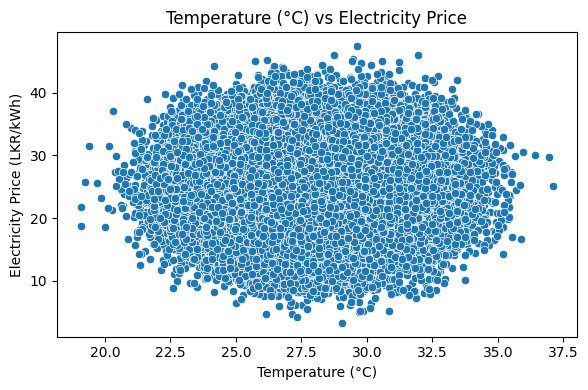

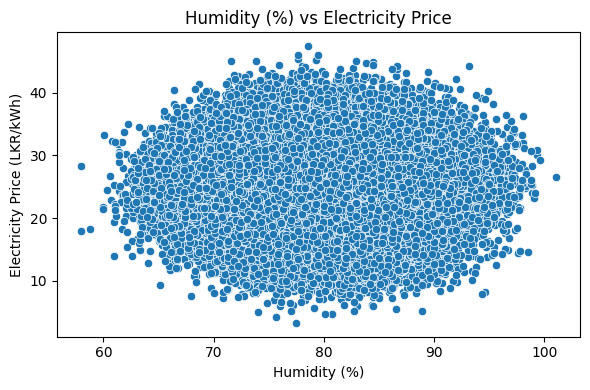

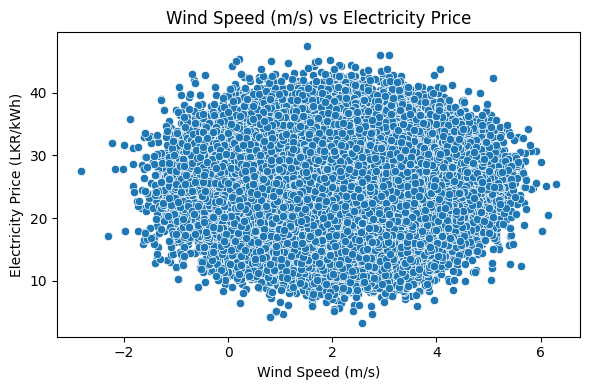

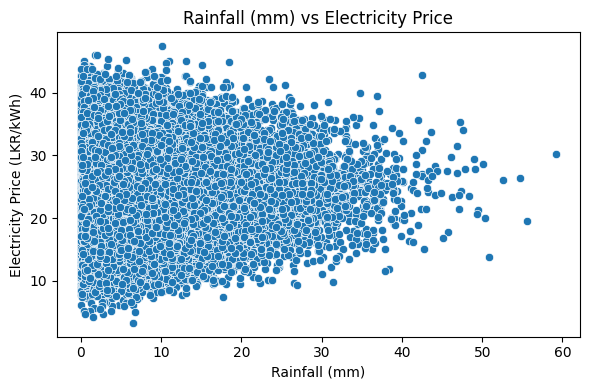

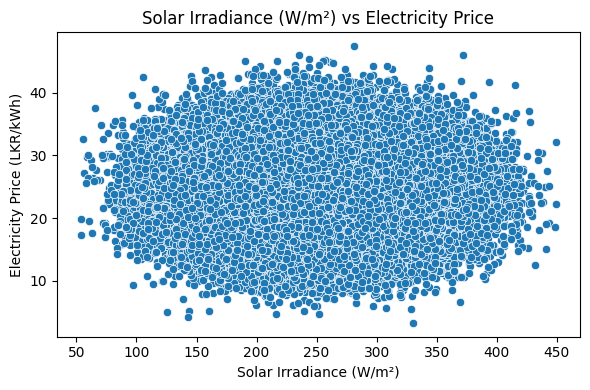

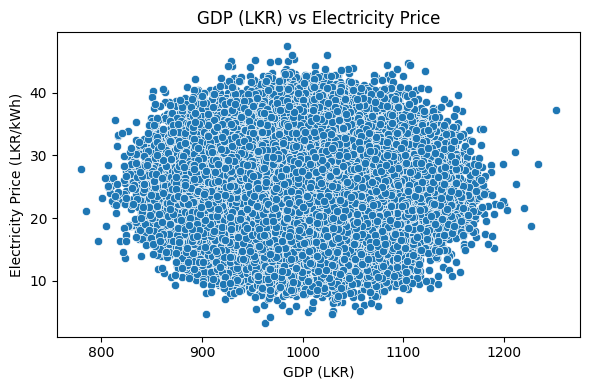

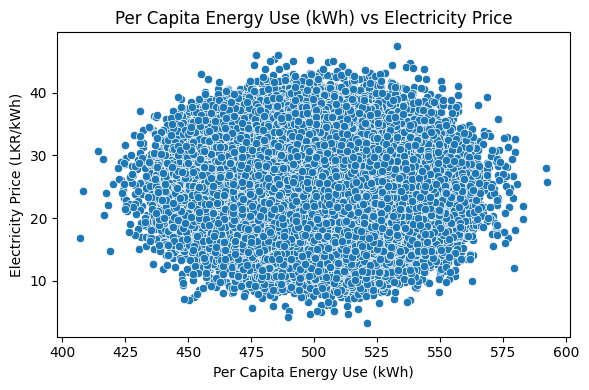

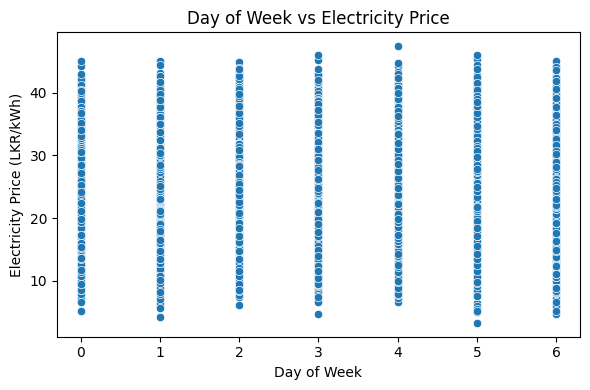

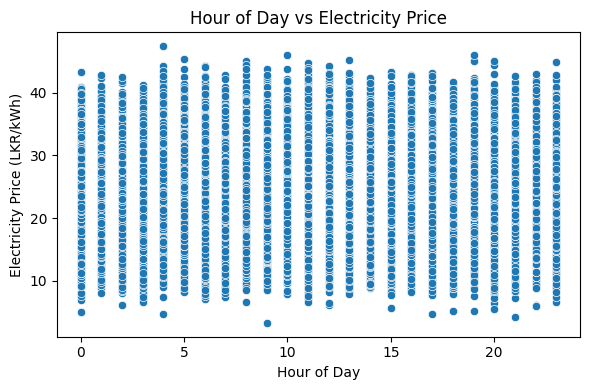

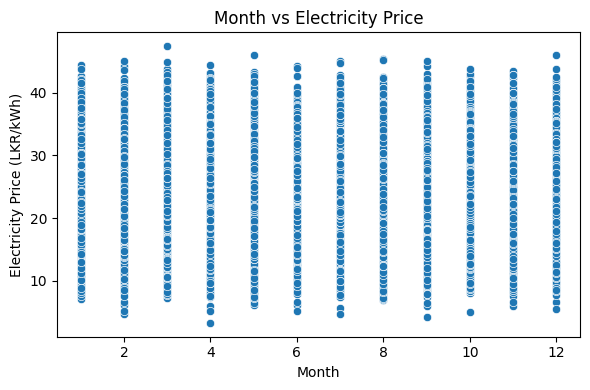

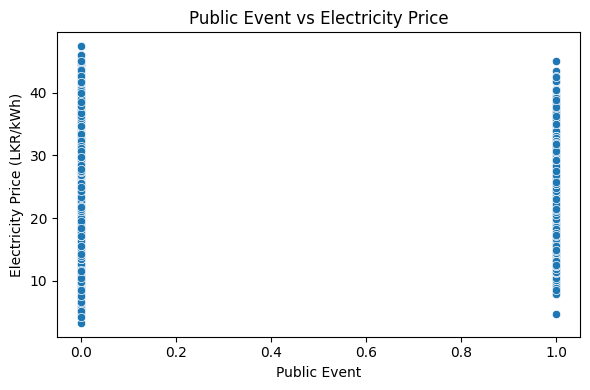

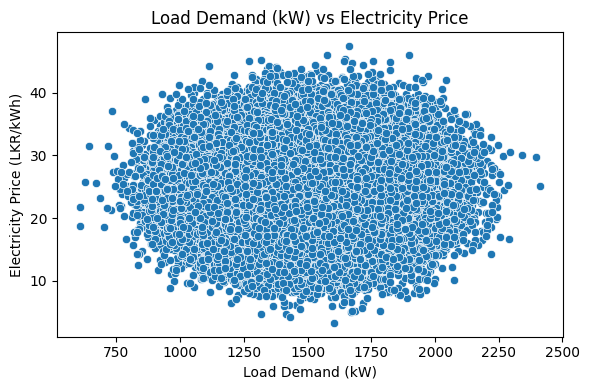

In [36]:
numeric_columns = df.columns.drop(['Season', 'Timestamp', 'Electricity Price (LKR/kWh)'])
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df['Electricity Price (LKR/kWh)'])
    plt.title(f'{col} vs Electricity Price')
    plt.tight_layout()
    plt.show()

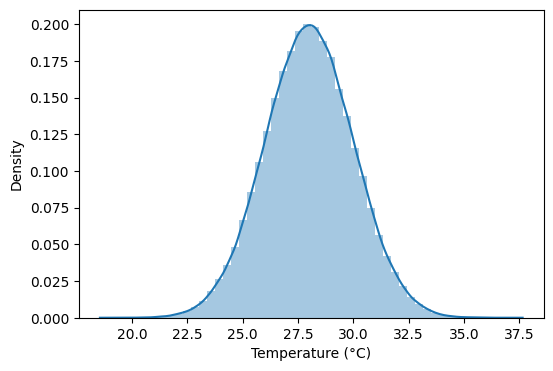

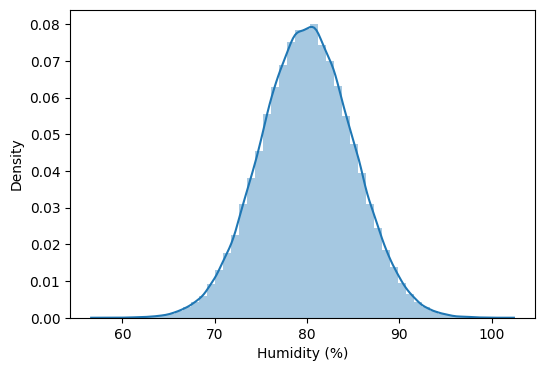

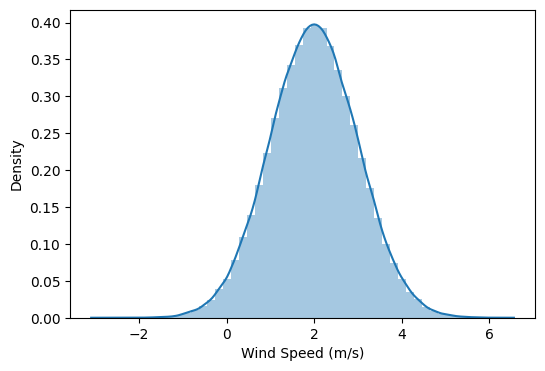

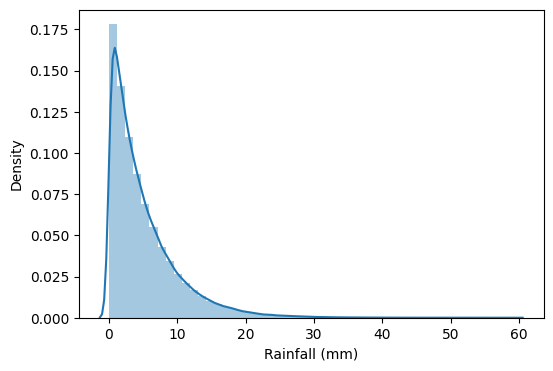

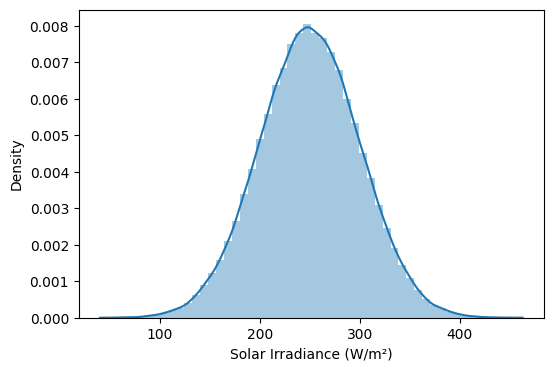

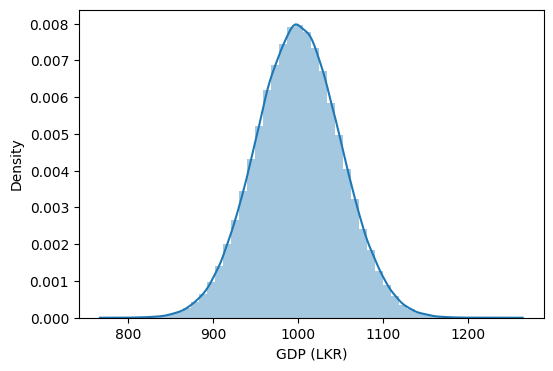

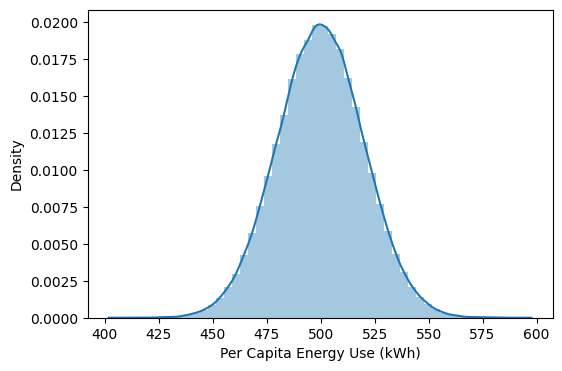

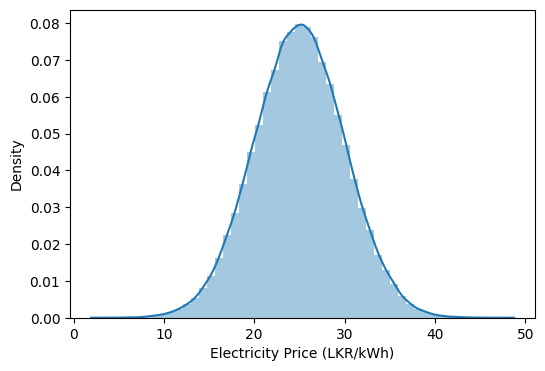

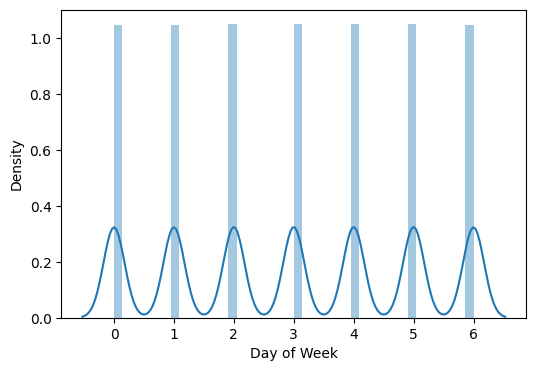

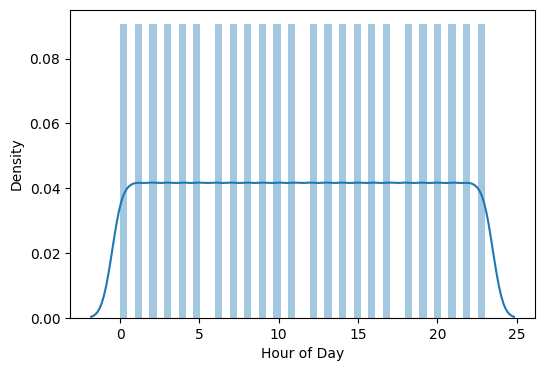

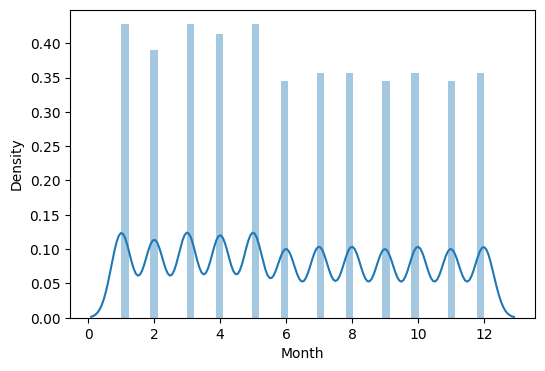

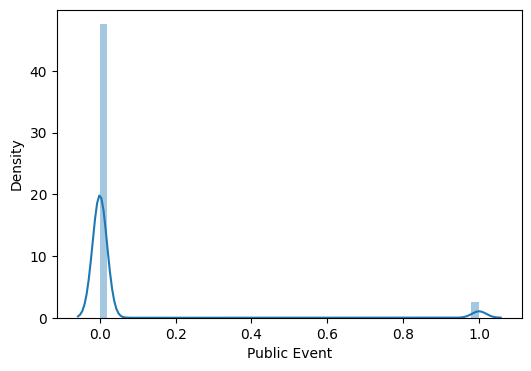

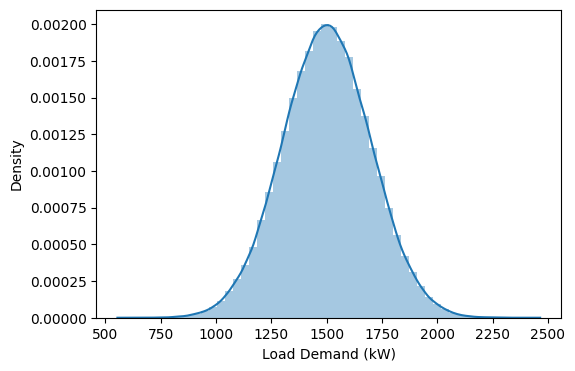

In [37]:
numeric_columns= df.columns.drop(['Season','Timestamp'])
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.distplot(df[col])
    plt.show()

In [38]:
model_df = pd.get_dummies(df, columns=["Season"], drop_first=True)
model_df


,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Public Event,Load Demand (kW),Season_Summer,Season_Winter
0,1/1/2020 0:00,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,0,1599.342831,True,False
1,1/1/2020 0:15,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,0,1472.347140,True,False
2,1/1/2020 0:30,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,0,1629.537708,True,False
3,1/1/2020 0:45,31.046060,87.615995,2.539148,1.038103,336.407064,937.963002,468.038834,26.032137,2,0,1,1,1804.605971,True,False
4,1/1/2020 1:00,27.531693,79.709858,1.366819,4.201393,205.494256,934.477462,488.565716,27.079114,2,1,1,0,1453.169325,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189883,5/31/2025 22:45,27.433177,82.943227,1.564385,0.476854,214.276578,986.122824,487.823955,17.183842,5,22,5,0,1443.317681,False,False
189884,5/31/2025 23:00,32.085127,84.159944,1.389473,0.309841,308.798749,970.258350,515.405431,29.773656,5,23,5,0,1908.512650,False,False
189885,5/31/2025 23:15,27.620201,87.091108,2.722335,1.422315,282.487744,1007.429961,509.295868,24.883951,5,23,5,0,1462.020111,False,False
189886,5/31/2025 23:30,29.378415,75.743129,2.317605,9.383305,246.291089,1019.239724,536.514530,27.765615,5,23,5,0,1637.841485,False,False


In [39]:
model_df[['Season_Summer','Season_Winter']].astype(int)

,Season_Summer,Season_Winter
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
189883,0,0
189884,0,0
189885,0,0
189886,0,0


In [40]:
cleaned_df=model_df.drop(['Timestamp'],axis=1).astype(int)
cleaned_df

cleaned_df['Timestamp'] = model_df['Timestamp']

In [41]:
cleaned_df

,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Public Event,Load Demand (kW),Season_Summer,Season_Winter,Timestamp
0,28,75,1,4,185,925,502,20,2,0,1,0,1599,1,0,1/1/2020 0:00
1,27,77,1,9,281,1020,497,27,2,0,1,0,1472,1,0,1/1/2020 0:15
2,29,74,3,4,328,1028,488,21,2,0,1,0,1629,1,0,1/1/2020 0:30
3,31,87,2,1,336,937,468,26,2,0,1,1,1804,1,0,1/1/2020 0:45
4,27,79,1,4,205,934,488,27,2,1,1,0,1453,1,0,1/1/2020 1:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189883,27,82,1,0,214,986,487,17,5,22,5,0,1443,0,0,5/31/2025 22:45
189884,32,84,1,0,308,970,515,29,5,23,5,0,1908,0,0,5/31/2025 23:00
189885,27,87,2,1,282,1007,509,24,5,23,5,0,1462,0,0,5/31/2025 23:15
189886,29,75,2,9,246,1019,536,27,5,23,5,0,1637,0,0,5/31/2025 23:30


In [42]:
cleaned_df.corr(numeric_only=True)

,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Public Event,Load Demand (kW),Season_Summer,Season_Winter
Temperature (°C),1.000000,-0.001765,-0.000708,-0.004337,0.001512,0.001260,0.001178,0.003196,-4.047711e-04,-2.306513e-03,-1.330866e-03,-0.004729,0.989717,-8.350017e-04,-7.126845e-04
Humidity (%),-0.001765,1.000000,-0.001259,0.000203,-0.001644,0.001599,0.001469,0.000079,3.477854e-04,1.020862e-03,1.679629e-03,-0.001269,-0.001093,3.537811e-03,-4.133148e-03
Wind Speed (m/s),-0.000708,-0.001259,1.000000,-0.002342,0.001397,0.002133,0.000816,0.000503,2.395816e-03,2.064998e-04,-5.987370e-04,0.001953,-0.001029,-1.289222e-03,-6.971047e-03
Rainfall (mm),-0.004337,0.000203,-0.002342,1.000000,-0.002373,0.000284,-0.003343,0.001734,-1.808271e-03,3.721615e-03,2.204269e-03,0.000248,-0.004566,4.103703e-04,6.080651e-03
Solar Irradiance (W/m²),0.001512,-0.001644,0.001397,-0.002373,1.000000,-0.000358,0.001414,-0.003018,1.175766e-03,-6.341918e-04,8.983703e-04,-0.001042,0.001685,-9.031932e-04,-1.397906e-04
GDP (LKR),0.001260,0.001599,0.002133,0.000284,-0.000358,1.000000,0.001874,0.000359,4.714268e-04,3.721025e-03,2.557576e-03,0.000015,0.001158,2.552241e-03,1.384917e-03
Per Capita Energy Use (kWh),0.001178,0.001469,0.000816,-0.003343,0.001414,0.001874,1.000000,0.001185,-1.328661e-03,2.295808e-03,1.815531e-03,0.000731,0.001554,2.419552e-03,1.597067e-03
Electricity Price (LKR/kWh),0.003196,0.000079,0.000503,0.001734,-0.003018,0.000359,0.001185,1.000000,2.898053e-03,1.376524e-03,-6.926726e-04,-0.000472,0.002846,-1.075047e-04,4.520010e-03
Day of Week,-0.000405,0.000348,0.002396,-0.001808,0.001176,0.000471,-0.001329,0.002898,1.000000e+00,1.764715e-18,6.198815e-04,-0.000164,-0.000472,3.168564e-03,-2.673392e-03
Hour of Day,-0.002307,0.001021,0.000206,0.003722,-0.000634,0.003721,0.002296,0.001377,1.764715e-18,1.000000e+00,3.405271e-16,0.000616,-0.002627,3.291511e-16,-6.277676e-16


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [69]:
x=cleaned_df[['Temperature (°C)']]
y=cleaned_df[['Load Demand (kW)']]

In [70]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [71]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((151910, 1), (37978, 1), (151910, 1), (37978, 1))

In [64]:
model=LinearRegression()

In [72]:
model.fit(x_train,y_train)

LinearRegression()

In [74]:
y_pred=model.predict(x_test)

In [75]:
r2_score(y_test,y_pred)

0.9794884932131938

In [76]:
ajusted_r2=1-(1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test)-1-1)
ajusted_r2

0.9794879530955725